# Unsupervised NLP Analysis of IMDB Movie Reviews

- **Name:** Shane Hans Uy  
- **Institution:** University of Santo Tomas (UST)  
- **Project Type:** Academic Data Science Project  

**Description:**  
This project was developed as part of an Artificial Intelligence course requirement. It applies unsupervised natural language processing techniques to discover hidden patterns in IMDB movie reviews. The workflow includes text preprocessing, TF-IDF vectorization, K-Means clustering, LDA topic modeling, and evaluation metrics to compare whether the discovered clusters and topics align with sentiment labels or capture broader review themes.

---

Importing all necessary libraries and setup.

In [1]:
#!pip install gensim pyLDAvis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA, TruncatedSVD

import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("All libraries loaded!")

All libraries loaded!


---

## Preprocessing and Vectorization

The IMDB movie review dataset was loaded and reduced to a random sample of 2,000 reviews using a fixed random state for reproducibility. The sentiment distribution was checked to understand the balance between positive and negative reviews before applying text preprocessing and feature extraction.

In [2]:
import pandas as pd

# Load the IMDB dataset
df = pd.read_csv(r"C:\Users\shane\OneDrive\Documents\UST - 2DSA2\Artificial Intelligence - 2nd Year\PROJECTS\Unsupervised NLP Analysis of IMDB Movie Reviews\IMDB Dataset.csv")

# Take a random sample of 2,000 reviews
sample_df = df.sample(n=2000, random_state=42)

# Separate text and labels
docs = sample_df["review"]
true_labels = sample_df["sentiment"]

# Print basic dataset information
print(f"Total reviews in full dataset: {len(df)}")
print(f"Total reviews in sample: {len(sample_df)}")

print("\nSentiment distribution in sample:")
print(true_labels.value_counts())

print("\nSentiment distribution in percentage:")
print(true_labels.value_counts(normalize=True) * 100)

print("\nSample review (first 300 chars):")
print(docs.iloc[0][:300])

Total reviews in full dataset: 50000
Total reviews in sample: 2000

Sentiment distribution in sample:
sentiment
negative    1024
positive     976
Name: count, dtype: int64

Sentiment distribution in percentage:
sentiment
negative    51.2
positive    48.8
Name: proportion, dtype: float64

Sample review (first 300 chars):
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok 


**Key Insights:** 

- The full IMDB dataset contains **50,000 reviews**, but a random sample of **2,000 reviews** was used to make the analysis more manageable.
- The sample contains **51.2% negative** and **48.8% positive** reviews. Indicating that the sample is almost balanced with only a small difference between negative and positive reviews

---

## Text Preprocessing

A preprocessing function was created to clean the raw IMDB review text. The function converted all text to lowercase, removed HTML tags, removed punctuation and numbers, tokenized the reviews, removed common stop words and domain-specific words, and applied lemmatization. The cleaned text was then stored for later analysis.

In [3]:
# Preprocessing pipeline
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Add domain-specific stop words
custom_stops = {'film', 'movie', 'one', 'make', 'even',
                'movies', 'watch', 'story', 'character', 'characters'}

stop_words = stop_words | custom_stops

def preprocess(text):
    text = text.lower()                           # (a) lowercase
    text = re.sub(r'<.*?>', '', text)              # (b) remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)        # (c) remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)                   # (d) tokenize
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 3]  # (e) remove stop words, (f) lemmatize
    return ' '.join(tokens)

print("Preprocessing reviews...")
processed_docs = [preprocess(doc) for doc in docs]
print(f"Done. Sample:")
print(processed_docs[0][:200])

Preprocessing reviews...
Done. Sample:
really liked summerslam look arena curtain look overall interesting reason anyways could best summerslams ever didnt luger main event yokozuna time huge strong glad time changed terrible main event li


**Key Insights:**

- The preprocessing function successfully cleaned the raw IMDB review text.
- The text was converted to lowercase to make word forms consistent. HTML tags, punctuation, and numbers were removed from the review text.
- Common stop words and domain-specific words such as “film,” “movie,” “one,” “make,” and “even” were removed.
- Lemmatization was applied to reduce words to their base form.

---

## Text Vectorization Using TF-IDF

The cleaned IMDB reviews were converted into a TF-IDF matrix using unigrams and bigrams. The vectorizer was limited to 2,000 selected features, while very rare terms and overly common terms were filtered out. L2 normalization was then applied to make the document vectors more consistent for comparison.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

# Build TF-IDF matrix
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    min_df=3,         # ignore terms appearing in fewer than 3 documents
    max_df=0.90       # ignore terms appearing in more than 90% of documents
)

X = tfidf.fit_transform(processed_docs)
X_norm = normalize(X)  # L2 normalize for cosine-like behavior

print(f"TF-IDF matrix shape: {X_norm.shape}")
print(f"(documents x features)")

TF-IDF matrix shape: (2000, 2000)
(documents x features)


**Key Insights:**

- The TF-IDF matrix has a shape of **(2000, 2000)**.
- Terms that appeared in fewer than 3 documents were removed.
- Terms that appeared in more than 90% of documents were also removed.
- L2 normalization was applied so the review vectors could be compared more consistently.

---

## Text Feature Filtering

The number of unique text features was checked before and after applying TF-IDF filtering. The initial feature set contained all extracted unigram and bigram terms, while the filtered feature set kept only the selected terms based on document frequency limits and the maximum feature count.

In [5]:
# Before filtering: unique tokens/features using only ngram_range
tfidf_before = TfidfVectorizer(
    ngram_range=(1, 2)
)

X_before = tfidf_before.fit_transform(processed_docs)
feature_names_before = tfidf_before.get_feature_names_out()

print(f"Unique tokens/features before filtering: {len(feature_names_before)}")


# After filtering: unique tokens/features after max_features, min_df, and max_df
feature_names_after = tfidf.get_feature_names_out()

print(f"Unique tokens/features after filtering: {len(feature_names_after)}")

print("\nSample tokens/features after filtering:")
print(feature_names_after[:20])

Unique tokens/features before filtering: 204754
Unique tokens/features after filtering: 2000

Sample tokens/features after filtering:
['abandoned' 'ability' 'able' 'absolute' 'absolutely' 'absurd' 'abuse'
 'accent' 'accept' 'acceptable' 'accident' 'according' 'account'
 'accurate' 'across' 'act' 'acted' 'acting' 'action' 'activity']


**Key Insights:**

- Before filtering, there were **204,754 unique tokens/features** extracted from the cleaned reviews.
- After applying the TF-IDF settings, only **2,000 selected features** were kept.
- The setting `min_df=3` removed terms that appeared in fewer than 3 reviews.
- The setting `max_df=0.90` removed terms that appeared in more than 90% of reviews.
- `min_df=3` and `max_df=90` helped reduce noise by removing words that may not be useful and also the words that are pretty common amongst all the other reviews.

---

## K-Means Text Clustering

K-Means clustering was used to group the IMDB reviews based on similarities in their TF-IDF text features. To choose an appropriate number of clusters, inertia values were compared using the elbow method for K values from 2 to 8. Silhouette scores were also computed to measure how well the reviews were separated into clusters.

Computing K-Means for K = 2 to 8...
  K=2: inertia=1906.6, silhouette=0.0038
  K=3: inertia=1898.6, silhouette=0.0025
  K=4: inertia=1893.1, silhouette=0.0024
  K=5: inertia=1889.8, silhouette=0.0021
  K=6: inertia=1886.1, silhouette=0.0025
  K=7: inertia=1883.8, silhouette=0.0037
  K=8: inertia=1879.0, silhouette=0.0023


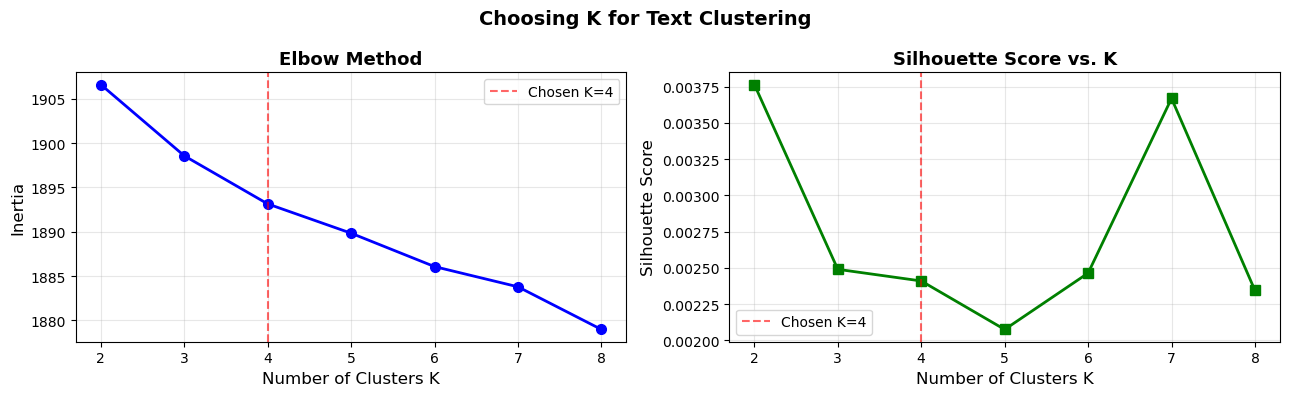

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Elbow method + Silhouette scores
K_range = range(2, 9)
inertias = []
silhouette_scores = []

print("Computing K-Means for K = 2 to 8...")

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=200,
        n_init=5,
        random_state=42
    )
    
    km.fit(X_norm)
    
    inertias.append(km.inertia_)
    
    sil = silhouette_score(
        X_norm,
        km.labels_,
        sample_size=500,
        random_state=42
    )
    
    silhouette_scores.append(sil)
    
    print(f"  K={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters K', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='Chosen K=4')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range), silhouette_scores, 'gs-', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Clusters K', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs. K', fontsize=13, fontweight='bold')
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='Chosen K=4')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Choosing K for Text Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insights:**

The elbow plot shows that inertia decreases as the number of clusters increases, with a slight bend around K = 4. However, the decrease is gradual, so the elbow is not very strong. The silhouette scores are also very low across all K values, which suggests that the review clusters are not clearly separated. Because of this, K = 4 can be treated as an initial choice, however additional validation such as the Davies-Bouldin Index is needed before finalizing the chosen K.

Computing Davies-Bouldin Index for K = 2 to 8...
  K=2: Davies-Bouldin Index=15.9561
  K=3: Davies-Bouldin Index=12.9563
  K=4: Davies-Bouldin Index=11.9679
  K=5: Davies-Bouldin Index=12.3588
  K=6: Davies-Bouldin Index=11.8963
  K=7: Davies-Bouldin Index=11.4068
  K=8: Davies-Bouldin Index=10.9198


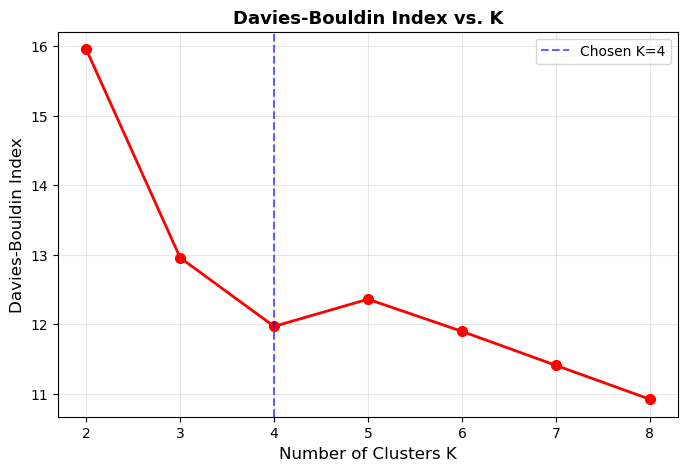

In [7]:
from sklearn.metrics import davies_bouldin_score

# Davies-Bouldin Index
db_scores = []

print("Computing Davies-Bouldin Index for K = 2 to 8...")

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=200,
        n_init=5,
        random_state=42
    )
    
    km.fit(X_norm)
    
    db = davies_bouldin_score(X_norm.toarray(), km.labels_)
    db_scores.append(db)
    
    print(f"  K={k}: Davies-Bouldin Index={db:.4f}")

# Plot Davies-Bouldin Index
plt.figure(figsize=(8, 5))
plt.plot(list(K_range), db_scores, 'ro-', linewidth=2, markersize=7)
plt.xlabel('Number of Clusters K', fontsize=12)
plt.ylabel('Davies-Bouldin Index', fontsize=12)
plt.title('Davies-Bouldin Index vs. K', fontsize=13, fontweight='bold')
plt.axvline(x=4, color='blue', linestyle='--', alpha=0.6, label='Chosen K=4')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Key Insights:**

The elbow plot does not show a clear bend, which means there is no obvious best value of K based on inertia alone. The inertia continues to decrease as K increases, which is expected because adding more clusters decreases WCSS. However, the silhouette scores remain very low across all K values, suggesting that the text clusters are not strongly separated.

The Davies-Bouldin Index gives its lowest value at K = 8, which means K = 8 has the best separation based on that metric. However, K = 8 was not chosen because using too many clusters may break the reviews into smaller, less interpretable groups. For this reason, K = 4 was selected as a more balanced choice because it keeps the clustering simpler and easier to interpret.

---

## Fitting K-Means with Chosen K and Cluster Labeling

The K-Means model was trained using the chosen value of K. For each cluster, the top 15 TF-IDF terms closest to the cluster centroid were identified. These terms were used to interpret the general theme of each cluster and assign descriptive labels to the review groups.

In [8]:
# Fit K-Means with chosen K
K = 4   

kmeans = KMeans(
    n_clusters=K,
    init='k-means++',   # smarter initialization
    max_iter=300,
    n_init=10,
    random_state=42
)

kmeans.fit(X_norm)

cluster_labels = kmeans.labels_

print("Documents per cluster:")
for i in range(K):
    count = (cluster_labels == i).sum()
    print(f"  Cluster {i}: {count} documents")

Documents per cluster:
  Cluster 0: 168 documents
  Cluster 1: 143 documents
  Cluster 2: 973 documents
  Cluster 3: 716 documents


**Key Insights:**

- K-Means was fitted using **K = 4**, producing four review clusters from the TF-IDF matrix.
- The clusters are uneven in size: **Cluster 2** has the most reviews with **973 documents**, followed by **Cluster 3** with **716 documents**.

In [9]:
feature_names = tfidf.get_feature_names_out()

# Descriptive labels based on top TF-IDF terms
cluster_names = {
    0: "Negative / Poor Quality Reviews",
    1: "TV Series / Episodes",
    2: "General Positive Reviews",
    3: "Acting and Scene-Based Reviews"
}

print("Top 15 terms per cluster:\n")
print(f"{'Cluster':<10} {'Descriptive Label':<35} {'Top Terms'}")
print("-" * 120)

for i in range(K):
    # Get centroid for this cluster
    centroid = kmeans.cluster_centers_[i]

    # Sort features by centroid weight
    top_indices = centroid.argsort()[::-1][:15]
    top_terms = [feature_names[j] for j in top_indices]

    print(f"Cluster {i:<2} {cluster_names[i]:<35} {', '.join(top_terms)}")

Top 15 terms per cluster:

Cluster    Descriptive Label                   Top Terms
------------------------------------------------------------------------------------------------------------------------
Cluster 0  Negative / Poor Quality Reviews     ever, seen, worst, ever seen, worst ever, best, time, plot, made, film, acting, like, would, funny, waste
Cluster 1  TV Series / Episodes                show, episode, series, season, like, good, people, great, funny, time, would, first, think, many, also
Cluster 2  General Positive Reviews            time, love, great, film, like, life, scene, also, good, well, year, first, many, woman, would
Cluster 3  Acting and Scene-Based Reviews      like, good, really, dont, would, time, better, much, could, thing, acting, think, people, well, scene


**Key Insights:**

- **Cluster 0** has terms such as *worst*, *worst ever*, *waste*, *plot*, and *acting*, so it was labeled as **Negative / Poor Quality Reviews**.
- **Cluster 1** contains terms such as *show*, *episode*, *series*, and *season*, so it appears to represent **TV Series / Episodes** rather than general movie reviews.
- **Cluster 2** includes terms such as *love*, *great*, *good*, *well*, *life*, and *scene*, which suggests a more **general positive review** pattern.
- **Cluster 3** contains broader review terms such as *like*, *good*, *really*, *better*, *acting*, *people*, and *scene*, so it was labeled as **Acting and Scene-Based Reviews**.
- Some terms appear across multiple clusters, such as *like*, *good*, *time*, *would*, and *scene*, which means the clusters are not completely distinct.
- The cluster labels are interpretive and based only on the top TF-IDF terms, so they describe possible themes rather than guaranteed categories.

---

## Cluster and Sentiment Cross-Tabulation

The K-Means cluster assignments were compared with the true sentiment labels using a cross-tabulation table. Each row represents a K-Means cluster, while each column represents the actual sentiment label. This comparison was used to check whether any cluster was mostly associated with either positive or negative reviews.

In [10]:
# Compare K-Means clusters to true sentiment labels

# Use the existing cluster labels from your fitted K-Means model
cluster_labels = kmeans.labels_

# Reset indexes so cluster labels and sentiment labels align correctly
cluster_series = pd.Series(cluster_labels, name="Cluster").reset_index(drop=True)
sentiment_series = pd.Series(true_labels, name="True Sentiment").reset_index(drop=True)

# Cross-tabulation
ct = pd.crosstab(cluster_series, sentiment_series)

print("Cluster vs. True Sentiment cross-tabulation:")
print(ct)

print("\nTotal reviews counted:", ct.values.sum())

Cluster vs. True Sentiment cross-tabulation:
True Sentiment  negative  positive
Cluster                           
0                    118        50
1                     63        80
2                    337       636
3                    506       210

Total reviews counted: 2000


**Key Insights:**

- **Cluster 0** contains **118 negative** and **50 positive** reviews, so it leans strongly toward negative sentiment.
- **Cluster 1** contains **63 negative** and **80 positive** reviews, making it the most mixed cluster with only a slight positive majority.
- **Cluster 2** contains **337 negative** and **636 positive** reviews, so it leans toward positive sentiment.
- **Cluster 3** contains **506 negative** and **210 positive** reviews, so it leans strongly toward negative sentiment.
- Clusters 0 and 3 are mostly negative, while Cluster 2 is mostly positive.
- However, no cluster is purely positive or purely negative, so the K-Means clusters only show **partial alignment** with the true sentiment labels.
- This suggests that K-Means captured some sentiment-related structure, but the reviews still contain overlapping words and themes across positive and negative labels.

---

## 2D Visualization of K-Means Clusters

TruncatedSVD was used to reduce the TF-IDF matrix into two dimensions for visualization. The resulting scatter plot shows each review as a point colored by its K-Means cluster, with black X markers representing the cluster centroids.

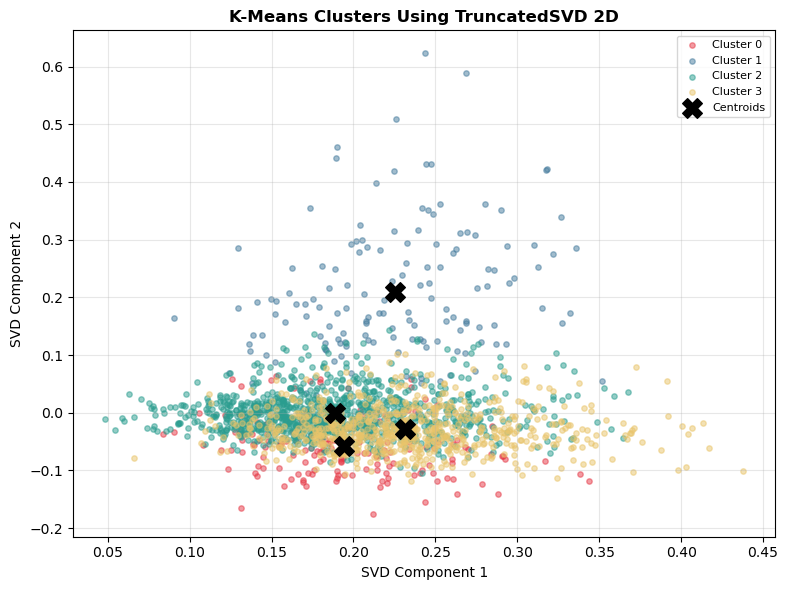

In [11]:
# Reduce to 2D for visualization
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_norm)

fig, ax = plt.subplots(figsize=(8, 6))

# Colors for clusters
colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A',
          '#A8DADC', '#F4A261', '#264653', '#8D99AE']

# Plot: K-Means cluster assignments
for i in range(K):
    mask = cluster_labels == i
    ax.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        c=colors[i],
        label=f'Cluster {i}',
        alpha=0.5,
        s=15
    )

# Plot centroids projected to 2D
centroids_2d = svd.transform(kmeans.cluster_centers_)

ax.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    c='black',
    marker='X',
    s=200,
    zorder=5,
    label='Centroids'
)

ax.set_title('K-Means Clusters Using TruncatedSVD 2D', fontsize=12, fontweight='bold')
ax.set_xlabel('SVD Component 1')
ax.set_ylabel('SVD Component 2')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Key Insights:**

- The TruncatedSVD plot shows a significant amount of overlap between the K-means clusters when viewing in the 2D space.
- Most reviews are concentrated just above the center of the plot.
- The clusters are not separated clearly into distinct regions, this explains the low silhouette scores gathered.
- The centroids are also very close to one another, showing that the clusters are not that far apart.
- The visualization shows that K-means found some groupings, but does not form well-separated clusters.

---

## Preparing the Corpus for LDA

The cleaned reviews were tokenized and converted into a Gensim dictionary. Rare terms and overly common terms were filtered out using `no_below=3` and `no_above=0.85`. The filtered text data was then transformed into a Bag-of-Words format for topic modeling.

In [12]:
from gensim import corpora

# Gensim needs: list of tokenized documents + a Dictionary

# Tokenize preprocessed reviews
tokenized_docs = [doc.split() for doc in processed_docs]

# Build dictionary (maps words to integer IDs)
dictionary = corpora.Dictionary(tokenized_docs)

# Filter extremes: remove very rare and very common words
dictionary.filter_extremes(no_below=3, no_above=0.85)

# Convert each document to Bag-of-Words (list of (word_id, count) tuples)
corpus_bow = [dictionary.doc2bow(doc) for doc in tokenized_docs]

print(f"Dictionary size: {len(dictionary)} unique terms")
print(f"Corpus size: {len(corpus_bow)} documents")
print(f"\nSample BoW for doc 0 (first 5 terms):")

for word_id, count in corpus_bow[0][:5]:
    print(f"  '{dictionary[word_id]}': {count}")

Dictionary size: 7843 unique terms
Corpus size: 2000 documents

Sample BoW for doc 0 (first 5 terms):
  'always': 1
  'another': 1
  'anyways': 1
  'best': 1
  'body': 2


**Key Insights:**

- The Gensim dictionary contains **7,843 unique terms** after filtering rare and overly common words.
- The sample Bag-of-Words output shows that words such as **always**, **another**, **anyways**, and **best** appeared once, while **body** appeared twice in the first document.
- The dictionary size is smaller than the earlier TF-IDF feature count before filtering, showing that the corpus was reduced to a more manageable vocabulary for topic modeling.

---

## LDA Topic Modeling

An LDA model was trained using the prepared Bag-of-Words corpus to identify four latent topics within the IMDB review dataset. The model was trained with 15 passes, automatic alpha and eta settings, and a fixed random state for reproducibility. After training, the top words for each topic were displayed with their probabilities to help interpret the themes discovered by the model.

In [13]:
from gensim.models import LdaModel

NUM_TOPICS = 4

lda_model = LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=15,           # number of training passes over the corpus
    alpha='auto',        # learn document-topic density automatically
    eta='auto',          # learn topic-word density automatically
    per_word_topics=True
)

print(f"LDA model trained with {NUM_TOPICS} topics.")
print(f"\nTop 12 words per topic:\n")

for i, topic in lda_model.print_topics(num_words=12):
    print(f"Topic {i}: {topic}")
    print()

LDA model trained with 4 topics.

Top 12 words per topic:

Topic 0: 0.010*"good" + 0.007*"great" + 0.006*"time" + 0.006*"show" + 0.006*"like" + 0.005*"well" + 0.005*"scene" + 0.005*"really" + 0.005*"love" + 0.005*"also" + 0.004*"best" + 0.004*"actor"

Topic 1: 0.013*"like" + 0.007*"would" + 0.007*"good" + 0.007*"time" + 0.006*"really" + 0.006*"dont" + 0.005*"could" + 0.005*"people" + 0.005*"much" + 0.005*"thing" + 0.004*"think" + 0.004*"made"

Topic 2: 0.007*"time" + 0.006*"like" + 0.005*"would" + 0.005*"life" + 0.005*"much" + 0.005*"really" + 0.005*"show" + 0.004*"people" + 0.004*"many" + 0.004*"never" + 0.004*"love" + 0.004*"first"

Topic 3: 0.006*"film" + 0.005*"time" + 0.005*"also" + 0.005*"like" + 0.004*"director" + 0.004*"life" + 0.004*"first" + 0.004*"role" + 0.004*"scene" + 0.003*"good" + 0.003*"work" + 0.003*"well"



**Key Insights:**

- Each topic is represented by a group of words with probability values, showing how strongly each word is associated with that topic.
- Some words, such as *good*, *like*, *time*, *show*, and *scene*, appear across multiple topics, which means the topics are not completely distinct.
- The word probabilities are relatively close to each other, so the LDA topics should be interpreted as broad themes rather than very clear categories.

---

## Topic Coherence Evaluation

The LDA model was evaluated using coherence scores to compare different numbers of topics. Models were trained with topic counts from K = 2 to K = 7, and the coherence score was computed for each one. The scores were then plotted to identify which number of topics produced the most meaningful and interpretable topic structure.

Computing coherence scores...
  K=2: coherence = 0.3124
  K=3: coherence = 0.3061
  K=4: coherence = 0.3071
  K=5: coherence = 0.3050
  K=6: coherence = 0.2891
  K=7: coherence = 0.2885


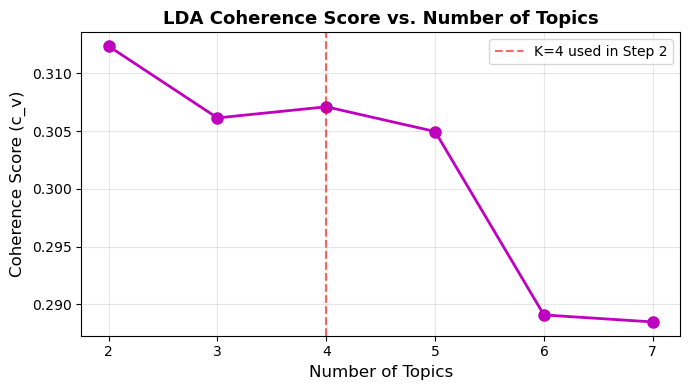


Highest coherence score: 0.3124
Best number of topics based on coherence: K = 2


In [14]:
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

# Compute coherence scores for K = 2 to 7
coherence_scores = []
topic_range = range(2, 8)

print("Computing coherence scores...")

for k in topic_range:
    model = LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=15,
        alpha='auto',
        eta='auto'
    )
    
    coherence = CoherenceModel(
        model=model,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    ).get_coherence()
    
    coherence_scores.append(coherence)
    
    print(f"  K={k}: coherence = {coherence:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(list(topic_range), coherence_scores, 'mo-', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='K=4 used in Step 2')
plt.xlabel('Number of Topics', fontsize=12)
plt.ylabel('Coherence Score (c_v)', fontsize=12)
plt.title('LDA Coherence Score vs. Number of Topics', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Find the K with the highest coherence score
best_k = list(topic_range)[coherence_scores.index(max(coherence_scores))]
best_score = max(coherence_scores)

print(f"\nHighest coherence score: {best_score:.4f}")
print(f"Best number of topics based on coherence: K = {best_k}")

**Key Insights:**

- The highest coherence score was found at **K = 2**, with a score of **0.3124**. This means that the 2-topic model produced the most coherent word groupings among the tested values. The 4-topic model used earlier had a slightly lower coherence score of **0.3071**, so it does not match the best coherence result. However, K = 4 can still be useful for exploring more detailed topics, while K = 2 gives a broader and simpler topic structure.

---

## Visualizing LDA Topics

A bar chart was created for each of the four LDA topics to show the top 10 words with the highest probabilities. These word distributions were used to interpret the topics and assign descriptive names based on their main themes.

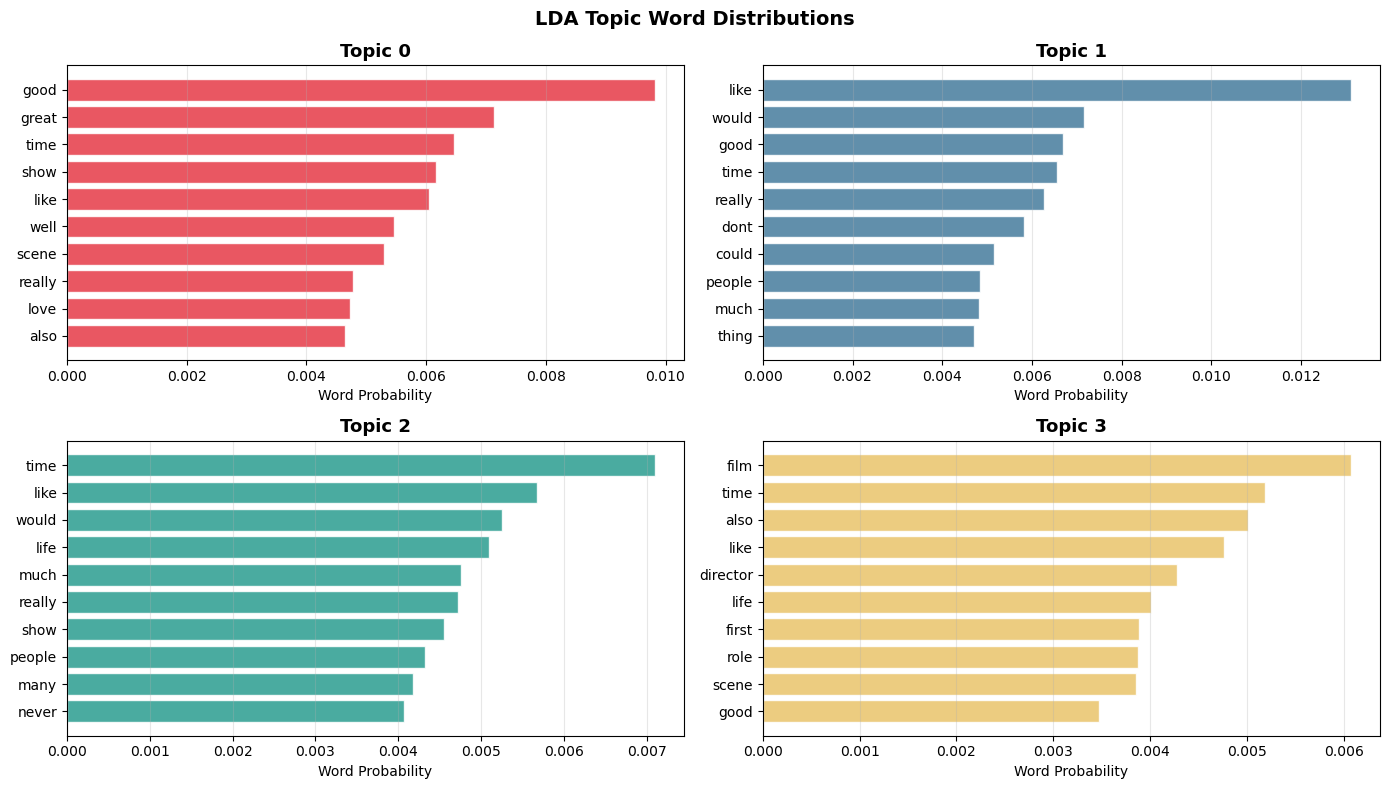

In [15]:
# Bar charts of top words per topic
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

topic_colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A']

for i in range(NUM_TOPICS):
    top_words = lda_model.show_topic(i, topn=10)
    words = [w for w, _ in top_words]
    probs = [p for _, p in top_words]

    axes[i].barh(
        words[::-1],
        probs[::-1],
        color=topic_colors[i],
        edgecolor='white',
        alpha=0.85
    )

    axes[i].set_title(f'Topic {i}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Word Probability', fontsize=10)
    axes[i].tick_params(labelsize=10)
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('LDA Topic Word Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insights:**

- The bar charts show the top 10 words for each of the four LDA topics, ranked by word probability.
- **Topic 0** is led by words such as *good*, *great*, *well*, *scene*, and *love*, so it can be interpreted as a **General Positive Reviews** topic.
- **Topic 1** is led by words such as *like*, *would*, *good*, *really*, *dont*, and *could*, so it appears to represent a **General Opinion / Personal Reaction** topic.
- **Topic 2** contains words such as *time*, *life*, *people*, *many*, and *never*, suggesting a **Story / Life and Character Reflection** topic.
- **Topic 3** includes words such as *film*, *director*, *role*, *scene*, and *work*, so it can be interpreted as a **Film Production / Performance** topic.
- Some words, such as *good*, *like*, *time*, and *scene*, appear across multiple topics, meaning the topics overlap and are not completely separate.
- Overall, the LDA model captured broad review themes rather than strict sentiment categories.

---

## Document-Topic Analysis

Each IMDB review was assigned a topic distribution using the trained LDA model. The resulting DataFrame shows the probability of each review belonging to Topic 0, Topic 1, Topic 2, and Topic 3, along with its sentiment label.

In [16]:
import numpy as np
import pandas as pd

# Get topic distribution for each document
def get_topic_vector(bow, model, num_topics):
    """Return a full topic probability vector for a document."""
    topic_dist = dict(model.get_document_topics(bow, minimum_probability=0))
    return [topic_dist.get(i, 0.0) for i in range(num_topics)]

topic_vectors = np.array([
    get_topic_vector(bow, lda_model, NUM_TOPICS)
    for bow in corpus_bow
])

# Store topic distribution vectors in a DataFrame
topic_df = pd.DataFrame(
    topic_vectors,
    columns=[f"Topic {i}" for i in range(NUM_TOPICS)]
)

# Add true sentiment labels
topic_df["sentiment"] = true_labels.values

print("Document-topic distribution DataFrame:")
print(topic_df.head())

print("\nDataFrame shape:")
print(topic_df.shape)

Document-topic distribution DataFrame:
    Topic 0   Topic 1   Topic 2   Topic 3 sentiment
0  0.996212  0.001883  0.001079  0.000825  positive
1  0.000618  0.000880  0.998117  0.000385  positive
2  0.389301  0.608212  0.001409  0.001078  negative
3  0.066120  0.002780  0.001591  0.929508  positive
4  0.000771  0.330835  0.667914  0.000481  negative

DataFrame shape:
(2000, 5)


**Key Insights:**

- Some reviews are strongly dominated by one topic, such as row 0 being mostly assigned to **Topic 0** and row 1 being mostly assigned to **Topic 2**.
- Other reviews have more mixed topic distributions, such as row 4, which has notable probabilities for both **Topic 1** and **Topic 2**.
- This output shows that LDA does not assign only one topic per review; instead, it represents each review as a mixture of topics.

---

## Topic Distribution Heatmap

The average topic probabilities were grouped by sentiment and visualized using a heatmap. This was used to check whether any LDA topic was more dominant in positive or negative IMDB reviews.

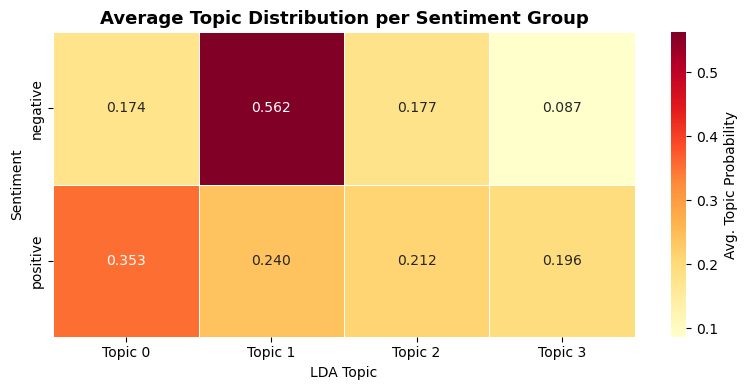


💡 Each row shows the average topic probabilities for one sentiment group.
   If one topic has a much higher value for positive or negative reviews,
   then that topic may be more strongly associated with that sentiment.


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap: average topic distribution per sentiment group
topic_df = pd.DataFrame(
    topic_vectors,
    columns=[f'Topic {i}' for i in range(NUM_TOPICS)]
)

topic_df['sentiment'] = true_labels.values

avg_topic_dist = topic_df.groupby('sentiment').mean()

plt.figure(figsize=(8, 4))

sns.heatmap(
    avg_topic_dist,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Avg. Topic Probability'}
)

plt.title('Average Topic Distribution per Sentiment Group', fontsize=13, fontweight='bold')
plt.ylabel('Sentiment')
plt.xlabel('LDA Topic')
plt.tight_layout()
plt.show()

print("\n💡 Each row shows the average topic probabilities for one sentiment group.")
print("   If one topic has a much higher value for positive or negative reviews,")
print("   then that topic may be more strongly associated with that sentiment.")

**Key Insights:**

- The heatmap shows the average topic probabilities for **negative** and **positive** reviews.
- **Negative reviews** are strongly dominated by **Topic 1**, with an average probability of **0.562**.
- **Positive reviews** are most associated with **Topic 0**, with an average probability of **0.353**.

---

## Dominant Topic Sample Reviews

Reviews with a dominant topic probability greater than 0.6 were selected to inspect how strongly individual documents were associated with a single LDA topic. Three sample reviews from the same dominant topic were printed along with their first 200 characters and topic probability values. This was used to check whether reviews assigned strongly to the same topic shared a common theme.

In [18]:
# Find documents with a dominant topic probability greater than 0.6
dominant_topics = topic_vectors.argmax(axis=1)
dominant_probs = topic_vectors.max(axis=1)

# Store dominant topic and probability in topic_df
topic_df["dominant_topic"] = dominant_topics
topic_df["dominant_probability"] = dominant_probs

# Find topics that have at least 3 documents with dominant probability > 0.6
qualified_docs = topic_df[topic_df["dominant_probability"] > 0.6]

print("Number of documents with dominant probability > 0.6 per topic:")
print(qualified_docs["dominant_topic"].value_counts())

# Select one topic that has at least 3 qualified documents
selected_topic = qualified_docs["dominant_topic"].value_counts().index[0]

print(f"\nSelected Topic: Topic {selected_topic}")
print("Printing 3 sample reviews with dominant probability > 0.6 on the same topic:\n")

# Get 3 sample reviews from the selected topic
sample_indices = qualified_docs[
    qualified_docs["dominant_topic"] == selected_topic
].head(3).index

for idx in sample_indices:
    print("=" * 100)
    print(f"Review Index: {idx}")
    print(f"Sentiment: {topic_df.loc[idx, 'sentiment']}")
    print(f"Dominant Topic: Topic {topic_df.loc[idx, 'dominant_topic']}")
    print(f"Dominant Probability: {topic_df.loc[idx, 'dominant_probability']:.3f}")
    
    print("\nReview text first 200 characters:")
    print(docs.iloc[idx][:200])
    
    print("\nTopic probabilities:")
    for t in range(NUM_TOPICS):
        print(f"  Topic {t}: {topic_vectors[idx][t]:.3f}")
    
    print()

Number of documents with dominant probability > 0.6 per topic:
dominant_topic
1    703
0    413
2    307
3    198
Name: count, dtype: int64

Selected Topic: Topic 1
Printing 3 sample reviews with dominant probability > 0.6 on the same topic:

Review Index: 2
Sentiment: negative
Dominant Topic: Topic 1
Dominant Probability: 0.608

Review text first 200 characters:
The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Seagal would have been beaten to pulp by Seagal's driving, but tha

Topic probabilities:
  Topic 0: 0.389
  Topic 1: 0.608
  Topic 2: 0.001
  Topic 3: 0.001

Review Index: 8
Sentiment: negative
Dominant Topic: Topic 1
Dominant Probability: 0.998

Review text first 200 characters:
I was very disappointed with this series. It had lots of cool graphics and that's about it. The level of detail it went into was minimal, and I always got the feeling the audience was being patronized

Topic probabiliti

**Key Insights:**

- **Topic 1** has the highest number of documents with dominant probability greater than **0.6**, with **703 reviews** assigned strongly to it.
- The three selected sample reviews all belong to **Topic 1** and are all labeled as **negative**.
- The dominant probabilities for the selected reviews are **0.608**, **0.998**, and **0.701**, meaning Topic 1 is the strongest topic in each of these reviews.
- The second review is almost entirely dominated by Topic 1, with a probability of **0.998**.
- The reviews share a common negative theme: they express disappointment or dissatisfaction with the movie/series.
- Topic 1 appears to capture a **negative opinion or criticism-based theme**.
- The first and third reviews still have some probability assigned to Topic 0, so not all documents are purely one-topic reviews.

---

The LDA topics only aligns a little bit with the sentiment labels, LDA captures common themes within a writing style, and repeated words in the reviews. It doesn't merely identify if its a positive or a negative review. Unlike, sentiment analysis that only identify if its positive or negative.

---

## K-Means Evaluation

The K-Means clustering results were evaluated using three metrics: silhouette score, Adjusted Rand Index, and Normalized Mutual Information. The silhouette score measures how well the reviews are separated into clusters, while ARI and NMI compare the K-Means cluster assignments with the true sentiment labels. These metrics help determine whether the clusters reflect the actual positive and negative sentiment structure of the IMDB reviews.

In [19]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# K-Means evaluation
ari = adjusted_rand_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
sil = silhouette_score(X_norm, cluster_labels, sample_size=500, random_state=42)

print("K-Means Clustering Evaluation")
print("=" * 40)
print(f"Silhouette Score:              {sil:.4f}  (higher is better, max=1)")
print(f"Adjusted Rand Index:           {ari:.4f}  (1=perfect, 0=random)")
print(f"Normalized Mutual Information: {nmi:.4f}  (1=perfect, 0=no info)")

K-Means Clustering Evaluation
Silhouette Score:              0.0024  (higher is better, max=1)
Adjusted Rand Index:           0.0900  (1=perfect, 0=random)
Normalized Mutual Information: 0.0688  (1=perfect, 0=no info)


**Key Insights:**

- The **silhouette score is 0.0024**, which is very close to zero. This means the K-Means clusters are not strongly separated from each other.
- The **Adjusted Rand Index is 0.0900**, which is low. This shows that the K-Means cluster assignments do not strongly match the true positive and negative sentiment labels.
- The **Normalized Mutual Information is 0.0688**, which is also low. This means there is only a small amount of shared information between the clusters and the sentiment labels.
- Overall, K-Means captured weak sentiment structure, but it did not clearly separate the reviews into positive and negative groups.
- These results support the earlier visualizations, where the clusters overlapped and were not clearly divided.

---

## LDA Dominant Topic Evaluation

Each review was assigned to its dominant LDA topic based on the topic with the highest probability in its document-topic distribution. The dominant topic assignments were then compared with the true sentiment labels using Adjusted Rand Index and Normalized Mutual Information. These metrics help measure whether the LDA topics align with the positive and negative sentiment structure of the reviews.

In [20]:
# Assign each document its dominant LDA topic
dominant_topics = topic_vectors.argmax(axis=1)

# LDA evaluation
lda_ari = adjusted_rand_score(true_labels, dominant_topics)
lda_nmi = normalized_mutual_info_score(true_labels, dominant_topics)

print("\nLDA Topic Model Evaluation (dominant topic assignment)")
print("=" * 55)
print(f"Adjusted Rand Index:           {lda_ari:.4f}")
print(f"Normalized Mutual Information: {lda_nmi:.4f}")


LDA Topic Model Evaluation (dominant topic assignment)
Adjusted Rand Index:           0.0949
Normalized Mutual Information: 0.0755


**Key Insights:**

- Each review was assigned to its **dominant LDA topic**, meaning the topic with the highest probability for that document.
- The **Adjusted Rand Index is 0.0949**, which is low. This means the LDA topic assignments do not strongly match the true positive and negative sentiment labels.
- The **Normalized Mutual Information is 0.0755**, which is also low. This shows that there is only a small amount of shared information between the LDA topics and the sentiment labels.
- Although some topics showed partial sentiment patterns earlier, the overall LDA topic assignments do not clearly separate positive and negative reviews.
- This suggests that LDA captures broader hidden themes and word patterns in the reviews rather than directly identifying sentiment.

---

## Comparison and Evaluation

| Method | Silhouette | ARI | NMI | Coherence |
|---|---:|---:|---:|---:|
| K-Means | 0.0024 | 0.0900 | 0.0688 | N/A |
| LDA | N/A | 0.0949 | 0.0755 | 0.3071 |

**Key Insights:**

Based on the results, **LDA slightly better recovers the sentiment structure** of the reviews because it has a higher ARI score of **0.0949** and a higher NMI score of **0.0755** compared to K-Means. However, both methods still have low ARI and NMI values, meaning neither method strongly matches the true positive and negative sentiment labels. 

For this dataset, topic modeling is more appropriate because it helps identify hidden themes, word patterns, and review context rather than only separating reviews into positive or negative groups. This shows that unsupervised methods are useful for exploring what the reviews discuss, but they are not as direct as sentiment analysis for predicting sentiment labels.

---

## Overall Conclusion

This project showed how unsupervised NLP techniques can be used to explore hidden patterns in IMDB movie reviews. Through preprocessing and TF-IDF vectorization, raw review text was converted into numerical features that could be used for clustering and topic modeling. K-Means clustering found some sentiment-related groupings, but the clusters were highly overlapping and did not strongly separate positive and negative reviews.

LDA topic modeling provided more interpretable results by identifying broad themes within the reviews. Some topics showed partial alignment with sentiment, such as Topic 1 being more associated with negative reviews and Topic 0 being more associated with positive reviews. However, the topics mostly captured general review patterns, opinions, story-related discussion, and film production terms rather than purely sentiment categories.

Based on the evaluation metrics, both K-Means and LDA had low alignment with the true sentiment labels, although LDA performed slightly better in terms of ARI and NMI. This means that unsupervised learning is useful for discovering hidden structure and themes in text, but it is not the best approach if the goal is to directly classify reviews as positive or negative. Overall, the project helped show the difference between discovering what reviews discuss and predicting how reviewers feel.